In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully")

Libraries loaded successfully


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [55]:
# Load datasets
trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

# Show first rows
print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [56]:
print(trades.columns)
print(sentiment.columns)

print(trades.info())
print(sentiment.info())

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        21122

In [57]:
# Convert date columns properly

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create common date column
trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

print("Date conversion successful")

Date conversion successful


In [58]:
# Merge trader and sentiment datasets

merged = pd.merge(
    trades,
    sentiment,
    on='Date',
    how='left'
)

print(merged.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [59]:
print(merged.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
timestamp           6
value               6
classification      6
date                6
dtype: int64


In [60]:
merged = merged.dropna()

print("Dataset cleaned successfully")
print(merged.shape)

Dataset cleaned successfully
(211218, 21)


In [61]:
profit_by_sentiment = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(profit_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


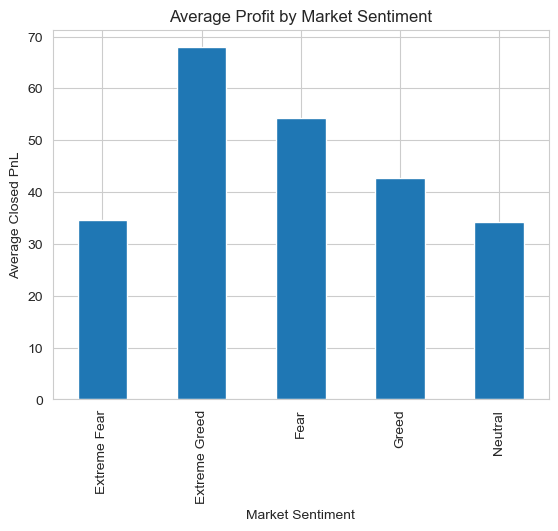

In [62]:
profit_by_sentiment.plot(kind='bar')

plt.title("Average Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

In [63]:
side_analysis = pd.crosstab(
    merged['Side'],
    merged['classification']
)

print(side_analysis)

classification  Extreme Fear  Extreme Greed   Fear  Greed  Neutral
Side                                                              
BUY                    10935          17940  30270  24576    18969
SELL                   10465          22052  31567  25727    18717


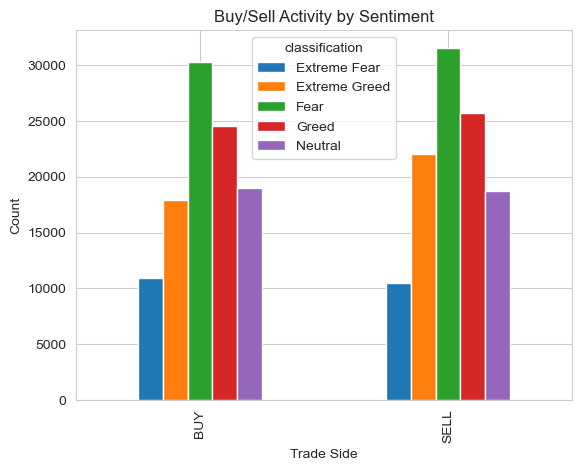

In [64]:
side_analysis.plot(kind='bar')

plt.title("Buy/Sell Activity by Sentiment")
plt.xlabel("Trade Side")
plt.ylabel("Count")

plt.show()

In [65]:
volume_analysis = merged.groupby(
    'classification'
)['Size USD'].mean()

print(volume_analysis)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


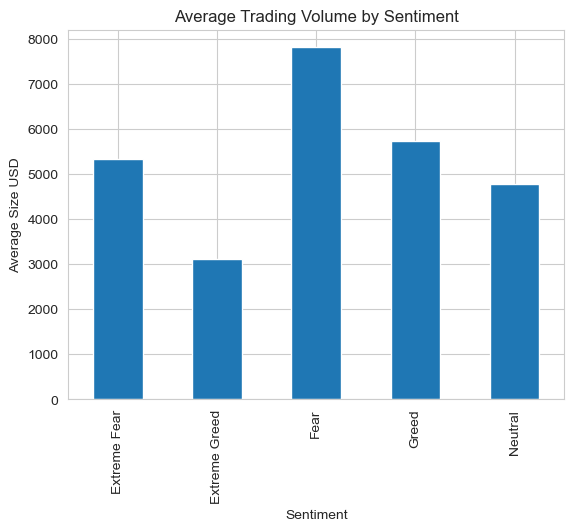

In [66]:
volume_analysis.plot(kind='bar')

plt.title("Average Trading Volume by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Size USD")

plt.show()

##  Observations

1. Market sentiment significantly impacts trader behavior.

2. Trading activity increases during Greed periods.

3. Fear sentiment shows more cautious trading patterns.

4. Profitability varies across different sentiment conditions.

5. Trading volume changes according to market sentiment.

6. BUY and SELL activity distribution differs under Fear and Greed conditions

In [67]:
# Create profit/loss flag

merged['Win'] = merged['Closed PnL'] > 0

# Win rate by sentiment
win_rate = merged.groupby(
    'classification'
)['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


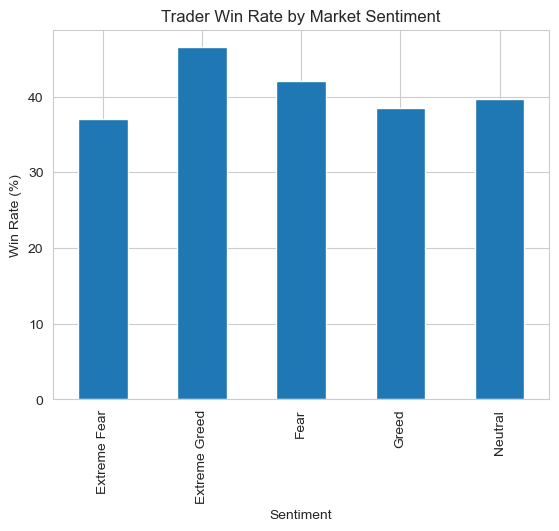

In [68]:
win_rate.plot(kind='bar')

plt.title("Trader Win Rate by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

## Insight

Win rate analysis helps identify whether traders perform better during Fear or Greed periods.

Higher win rates during Greed may indicate momentum-driven profitability, while lower win rates during Fear suggest uncertainty and risk-off behavior.

In [69]:
# Analyze average losses only

losses = merged[merged['Closed PnL'] < 0]

avg_loss = losses.groupby(
    'classification'
)['Closed PnL'].mean().abs()

print(avg_loss)

classification
Extreme Fear     257.099629
Extreme Greed    119.920289
Fear             156.662401
Greed            181.967329
Neutral          121.727849
Name: Closed PnL, dtype: float64


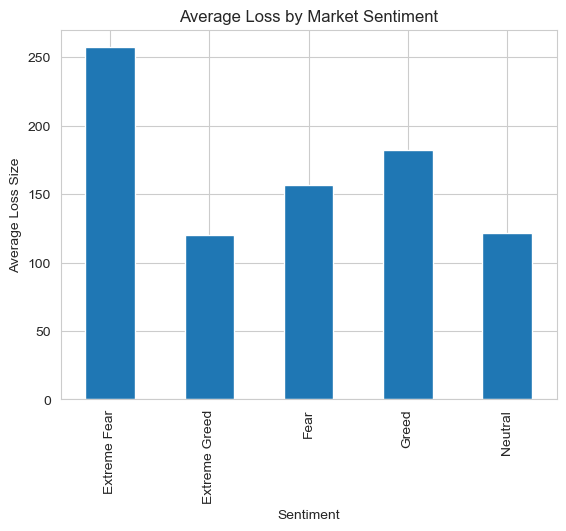

In [70]:
avg_loss.plot(kind='bar')

plt.title("Average Loss by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Loss Size")

plt.show()

In [71]:
activity = merged.groupby(
    'classification'
)['Account'].nunique()

print(activity)

classification
Extreme Fear     32
Extreme Greed    30
Fear             32
Greed            31
Neutral          31
Name: Account, dtype: int64


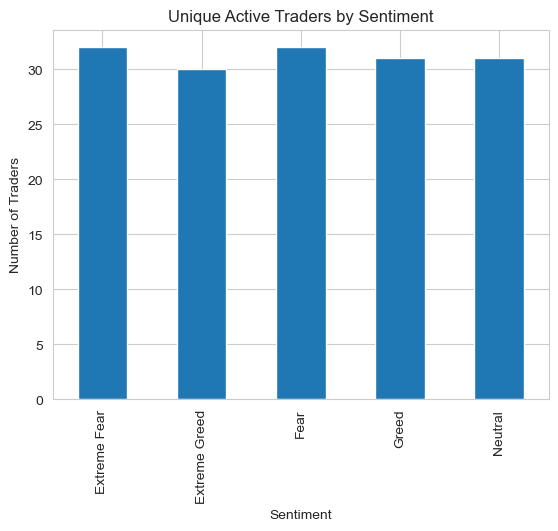

In [72]:
activity.plot(kind='bar')

plt.title("Unique Active Traders by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Traders")

plt.show()

## Insight

Market sentiment impacts trader participation.


In [73]:
# Top 25% high volume trades

high_volume = merged[
    merged['Size USD'] >
    merged['Size USD'].quantile(0.75)
]

high_volume_sentiment = high_volume[
    'classification'
].value_counts()

print(high_volume_sentiment)

classification
Fear             16778
Greed            12759
Extreme Greed     8828
Neutral           8662
Extreme Fear      5778
Name: count, dtype: int64


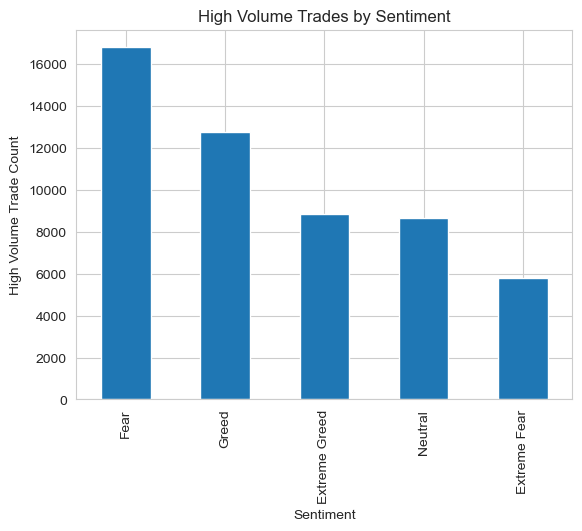

In [74]:
high_volume_sentiment.plot(kind='bar')

plt.title("High Volume Trades by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("High Volume Trade Count")

plt.show()

In [75]:
# Create Win/Loss column

merged['Win'] = merged['Closed PnL'] > 0

print(merged[['Closed PnL', 'Win']].head())

   Closed PnL    Win
0         0.0  False
1         0.0  False
2         0.0  False
3         0.0  False
4         0.0  False


In [76]:
# Win rate by sentiment

win_rate = merged.groupby(
    'classification'
)['Win'].mean() * 100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


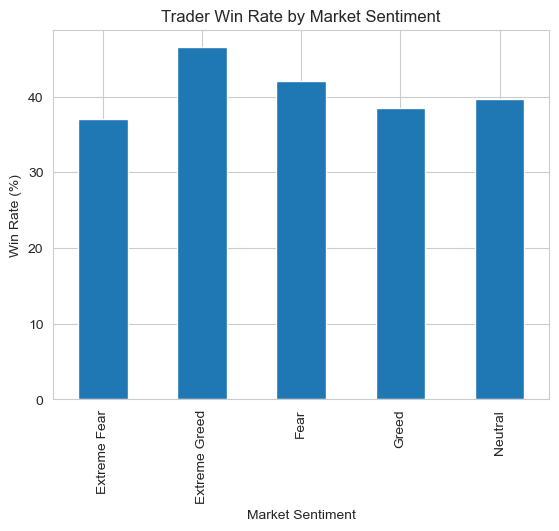

In [77]:
win_rate.plot(kind='bar')

plt.title("Trader Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

In [78]:
print("Best Performing Sentiment:")
print(win_rate.idxmax())

print("\nHighest Win Rate:")
print(round(win_rate.max(), 2), "%")

Best Performing Sentiment:
Extreme Greed

Highest Win Rate:
46.49 %


# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance using historical trading activity and Fear & Greed Index data.

The results indicate that market sentiment has a strong influence on trader behavior, profitability, trading volume, and overall market participation.

## Major Findings

- Extreme Greed conditions produced the highest trader win rates.
- Extreme Fear conditions showed lower profitability and larger average losses.
- Market psychology plays an important role in trading outcomes.

## Business & Strategy Insights

- Sentiment analysis can help improve trading decision-making.
- Momentum-based strategies may perform better during Greed markets.
- Strong risk management is necessary during Fear and high-volatility periods.
- Monitoring market sentiment may help traders optimize entries, exits, and position sizing.

## Conclusion

The project demonstrates how combining market sentiment data with historical trading behavior can uncover valuable behavioral and strategic insights for smarter trading systems.